# Import necessary libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report
from sklearn.feature_selection import SelectFromModel

In [2]:
df=pd.read_csv('feature_time_48k_2048_load_1.csv')

In [3]:
df.head()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1


# Adding more feactures to the dataset

In [4]:
df["range"]=df["max"]-df["min"]
df["impulse"]=df["crest"]*df["form"]
df.head()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault,range,impulse
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1,0.77876,20.171003
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1,0.82883,21.016591
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1,0.90664,22.889264
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1,1.12778,27.898738
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1,1.02576,20.158031


In [5]:
df.shape

(2300, 12)

# Feature Selection from Random Forest

In [6]:
x=df.drop('fault',axis=1)
y=df.fault

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
selector = SelectFromModel(rf, prefit=True)
x_train_selected = selector.transform(x_train)
x_test_selected = selector.transform(x_test)

C:\Users\dell\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [3]:
scaler = StandardScaler()  # to scale down 

x_train_selected = scaler.fit_transform(x_train_selected)
x_test_selected = scaler.transform(x_test_selected)

NameError: name 'x_train_selected' is not defined

In [10]:
selected_features = x_train.columns[selector.get_support()]
print(selected_features)


Index(['mean', 'sd', 'rms', 'kurtosis', 'range'], dtype='str')


   ['mean', 'sd', 'rms', 'kurtosis', 'range'] have more influence on the output 

# Train and Test the SVM on the Selected Features

In [51]:
svm = SVC(kernel="rbf", C=1, gamma="scale")

svm.fit(x_train_selected, y_train)
y_pred = svm.predict(x_test_selected)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9434782608695652
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        70
           1       1.00      0.78      0.88        78
           2       0.93      0.85      0.89        74
           3       0.98      1.00      0.99        57
           4       1.00      1.00      1.00        66
           5       0.97      1.00      0.98        61
           6       0.94      1.00      0.97        61
           7       1.00      1.00      1.00        72
           8       0.78      0.95      0.86        76
           9       0.97      0.99      0.98        75

    accuracy                           0.94       690
   macro avg       0.95      0.95      0.95       690
weighted avg       0.95      0.94      0.94       690



# HyperParameter Tuning

In [12]:
pipeline = Pipeline([
    ("feature_selection", SelectFromModel(RandomForestClassifier(random_state=42))),
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

In [13]:
param_grid = {
    "feature_selection__estimator__n_estimators": [100, 200],
    "feature_selection__estimator__max_depth": [None, 10, 20],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.001],
    "svm__kernel": ["rbf", "linear"]
}


In [ ]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train and test RF-SVM model on best parameters

In [52]:
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'feature_selection__estimator__max_depth': [None, 10, ...], 'feature_selection__estimator__n_estimators': [100, 200], 'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 0.01, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the 

In [53]:
print("Best Parameters:")
print(grid.best_params_)


Best Parameters:
{'feature_selection__estimator__max_depth': None, 'feature_selection__estimator__n_estimators': 100, 'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


In [16]:
y_pred = grid.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9623188405797102
              precision    recall  f1-score   support

  Ball_007_1       0.94      0.93      0.94        70
  Ball_014_1       0.97      0.94      0.95        78
  Ball_021_1       0.94      0.89      0.92        74
    IR_007_1       0.98      1.00      0.99        57
    IR_014_1       1.00      1.00      1.00        66
    IR_021_1       0.95      1.00      0.98        61
    Normal_1       0.97      1.00      0.98        61
  OR_007_6_1       1.00      1.00      1.00        72
  OR_014_6_1       0.88      0.92      0.90        76
  OR_021_6_1       1.00      0.97      0.99        75

    accuracy                           0.96       690
   macro avg       0.96      0.97      0.96       690
weighted avg       0.96      0.96      0.96       690



accuracy improve from 0.94 to 0.96

# Plotting the decision trees from Random Forest

In [17]:
rf_model = grid.best_estimator_.named_steps["feature_selection"].estimator_

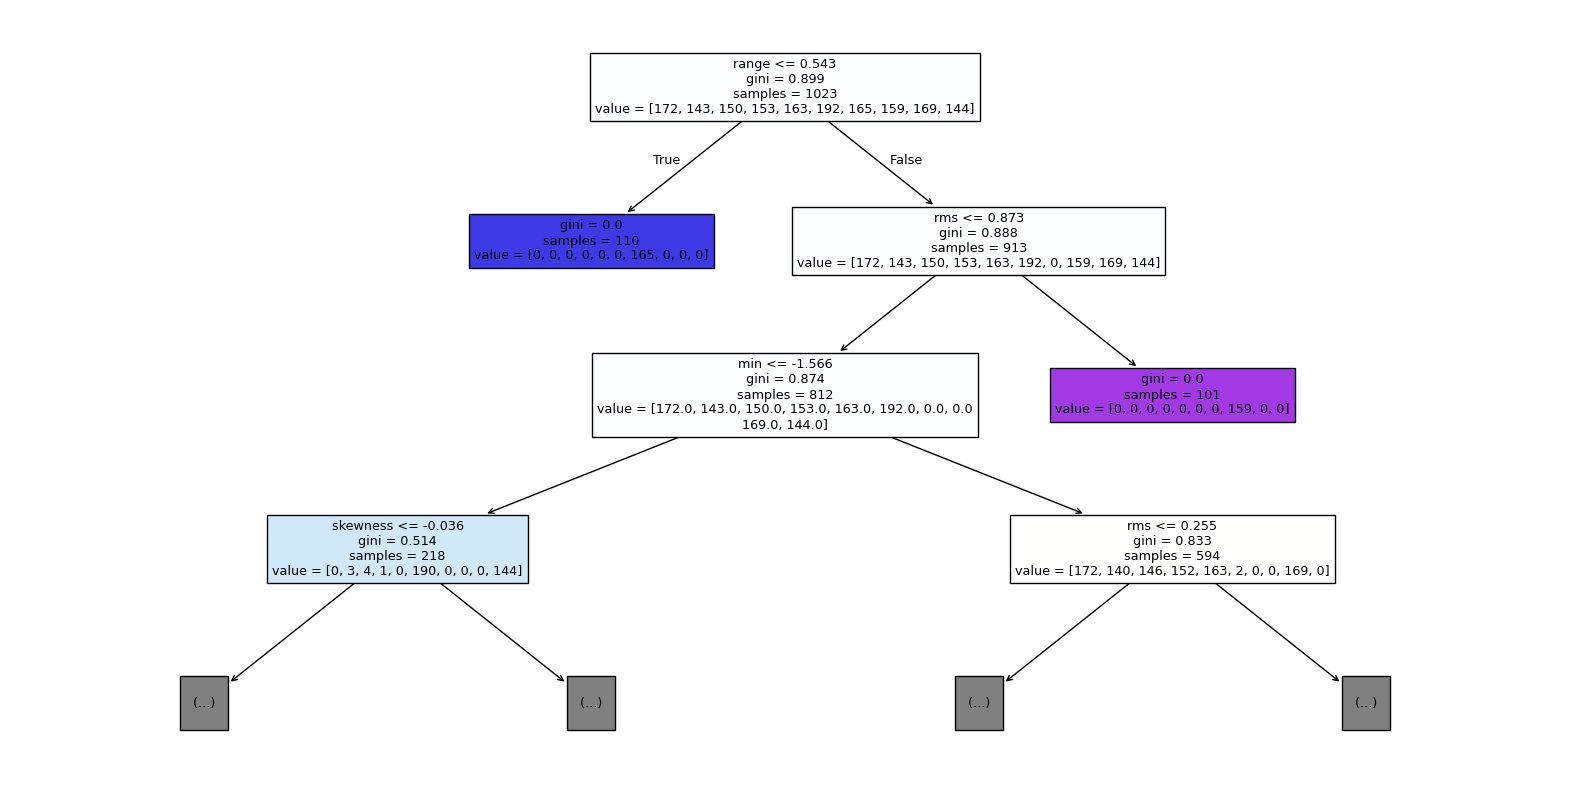

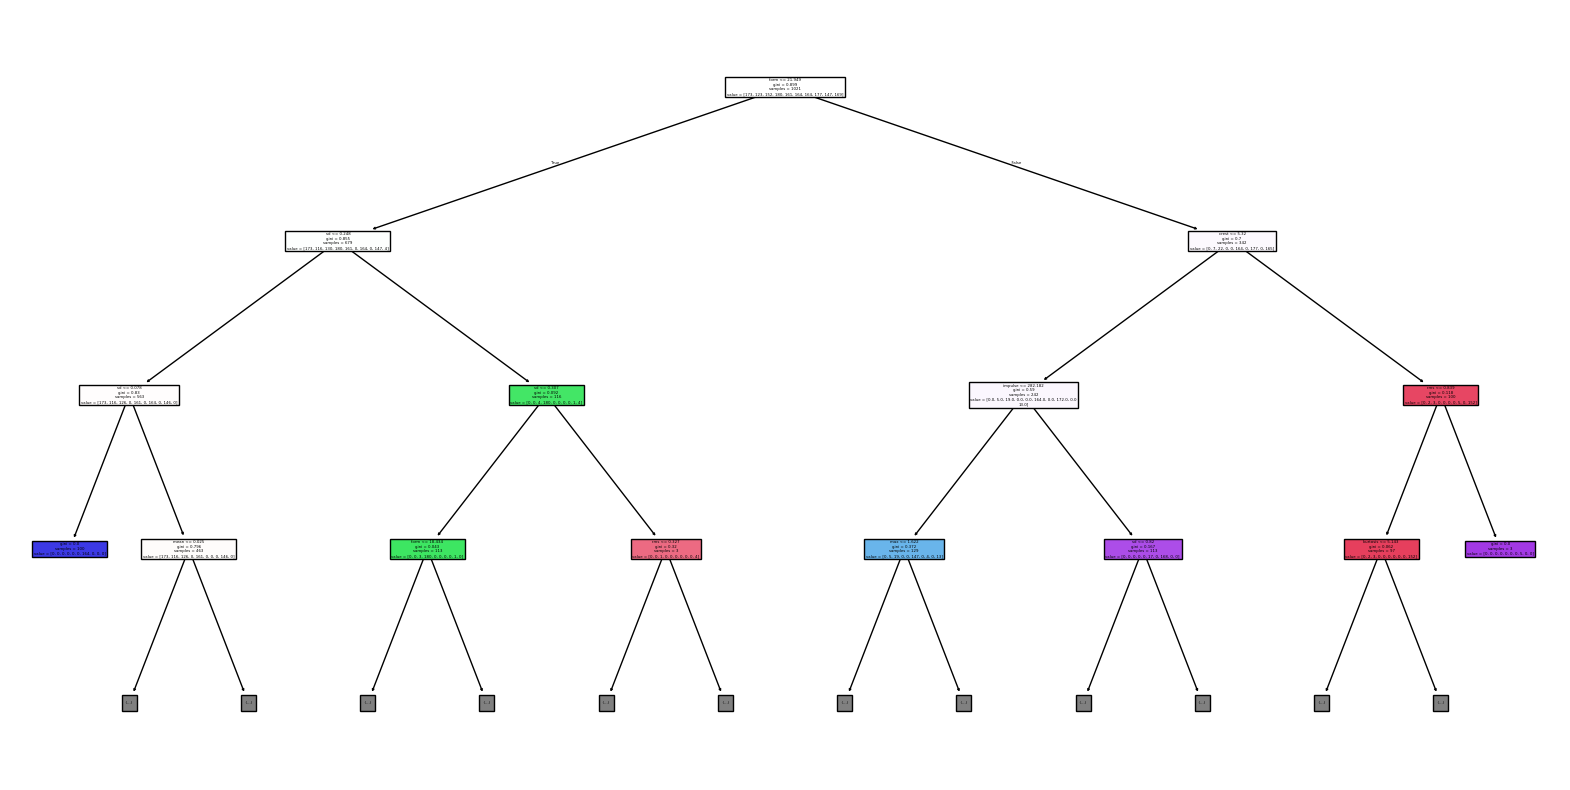

In [28]:
from sklearn.tree import plot_tree

for i in range(2):
    tree = rf_model.estimators_[i]

    plt.figure(figsize=(20,10))
    plot_tree(tree, filled=True, max_depth=3, feature_names=x_train.columns)
    plt.show()